# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [ ]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
# Load cleaned aviation data
df = pd.read_csv("data/AviationData_Clean.csv")

# Verify the data loaded correctly
display(df.head())
print(df.shape)

/tmp/ipykernel_1917/1726842757.py:2: DtypeWarning: Columns (0: Event.Id, 28: Broad.phase.of.flight) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/AviationData_Clean.csv")


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date,Total.People,Serious.Fatal.Rate,Destroyed,Plane.Type
0,20001214X42478,Incident,LAX83IA149A,1983-03-18,"LOS ANGELES, CA",United States,NaN,NaN,LAX,LOS ANGELES INTL,...,0.0,588.0,VMC,Taxi,Probable Cause,04-12-2014,588.0,0.0,0.0,BOEING 747
1,20001214X42331,Accident,ATL83FA140,1983-03-20,"CROSSVILLE, TN",United States,NaN,NaN,NaN,NaN,...,0.0,0.0,IMC,Cruise,Probable Cause,02-05-2011,2.0,1.0,1.0,PIPER PA-28-140
2,20001214X42672,Accident,FTW83LA177,1983-04-02,"MCKINNEY, TX",United States,NaN,NaN,TX05,AERO COUNTRY,...,0.0,4.0,VMC,Standing,Probable Cause,17-10-2016,5.0,0.2,NaN,DE HAVILLAND DHC-6
3,20001214X45013,Incident,CHI84IA041,1983-11-08,"CHICAGO, IL",United States,NaN,NaN,ORD,O'HARE,...,0.0,100.0,VMC,Taxi,Probable Cause,11-06-2018,100.0,0.0,0.0,BOEING 727-200
4,20001214X45188,Accident,NYC84LA028,1983-11-13,"MARTHA'S VINEYARD, MA",United States,NaN,NaN,NaN,NaN,...,0.0,1.0,VMC,Climb,Probable Cause,05-05-2011,1.0,0.0,0.0,BEECH C35


(17879, 35)


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [9]:
# Separate small and large aircraft using a passenger threshold of 20
small_planes = df[df["Total.People"] < 20].copy()
large_planes = df[df["Total.People"] >= 20].copy()

# Check the size of each group
print("Small aircraft:", len(small_planes))
print("Large aircraft:", len(large_planes))

Small aircraft: 17001
Large aircraft: 878


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

Make
MCDONNELL DOUGLAS                 0.094048
BOMBARDIER INC                    0.100000
BOMBARDIER                        0.103846
BOEING                            0.141973
AVIAT AIRCRAFT INC                0.164474
MAULE                             0.164806
GRUMMAN ACFT ENG COR-SCHWEIZER    0.206897
AYRES                             0.215686
STINSON                           0.216408
AVIAT                             0.221429
BELLANCA                          0.222603
DIAMOND AIRCRAFT IND INC          0.222973
ROCKWELL INTERNATIONAL            0.223684
AERONCA                           0.225833
DEHAVILLAND                       0.231652
Name: Serious.Fatal.Rate, dtype: float64

Make
DEHAVILLAND                  0.000000
CESSNA                       0.000000
PIPER                        0.000000
GRUMMAN                      0.000000
MCDONNELL DOUGLAS            0.007827
BOMBARDIER INC               0.028038
BOEING                       0.056771
BOMBARDIER                   0.063701
EMBRAER                      0.065274
AIRBUS                       0.086249
RAYTHEON AIRCRAFT COMPANY    0.150000
DE HAVILLAND                 0.289526
BEECH                        1.000000
Name: Serious.Fatal.Rate, dtype: float64

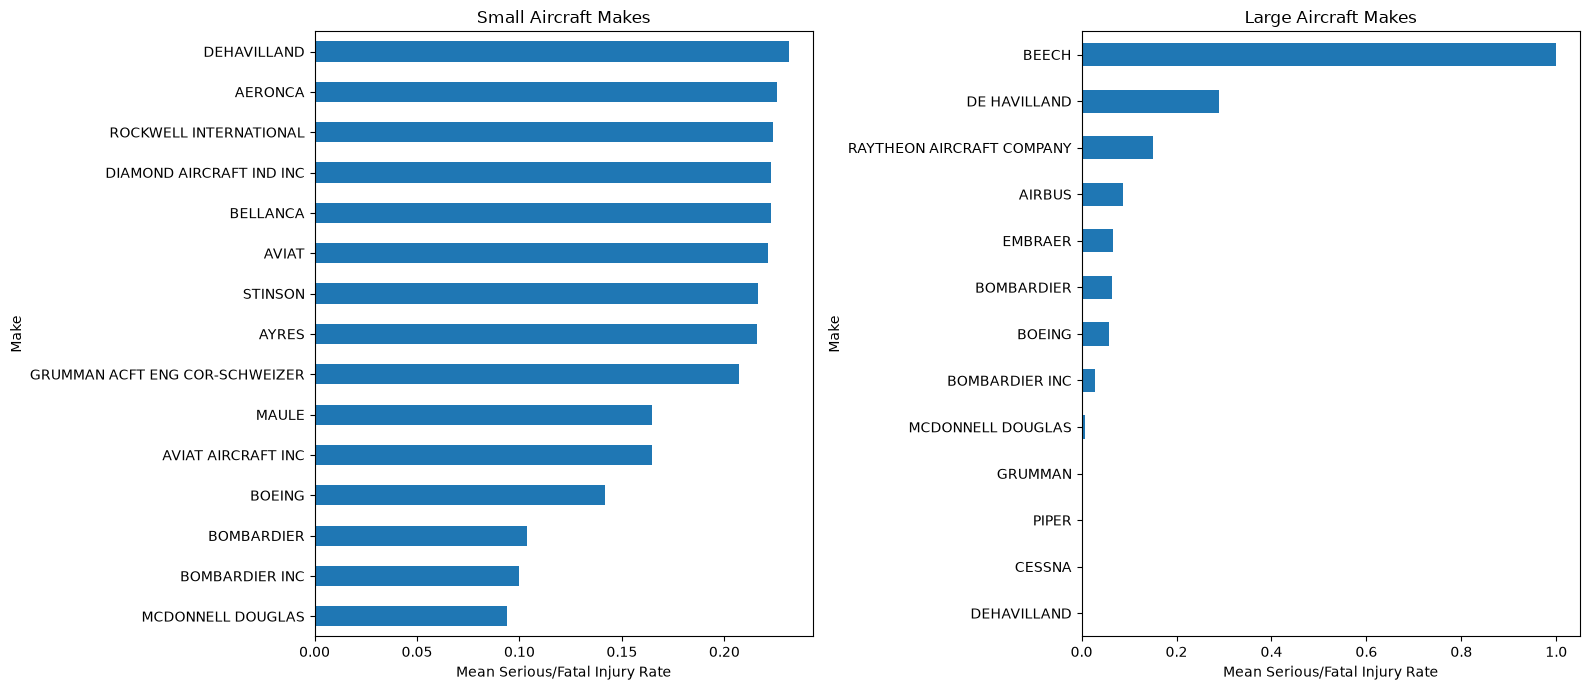

In [10]:
# Calculate mean serious/fatal injury rate by make for small aircraft
small_make_rates = (
    small_planes.groupby("Make")["Serious.Fatal.Rate"]
    .mean()
    .sort_values()
    .head(15)
)

display(small_make_rates)

large_make_rates = (
    large_planes.groupby("Make")["Serious.Fatal.Rate"]
    .mean()
    .sort_values()
    .head(15)
)

display(large_make_rates)

# Plot the 15 makes with the lowest mean serious/fatal injury rates
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Small aircraft
small_make_rates.sort_values().plot(
    kind="barh",
    ax=axes[0]
)
axes[0].set_title("Small Aircraft Makes")
axes[0].set_xlabel("Mean Serious/Fatal Injury Rate")
axes[0].set_ylabel("Make")

# Large aircraft
large_make_rates.sort_values().plot(
    kind="barh",
    ax=axes[1]
)
axes[1].set_title("Large Aircraft Makes")
axes[1].set_xlabel("Mean Serious/Fatal Injury Rate")
axes[1].set_ylabel("Make")

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

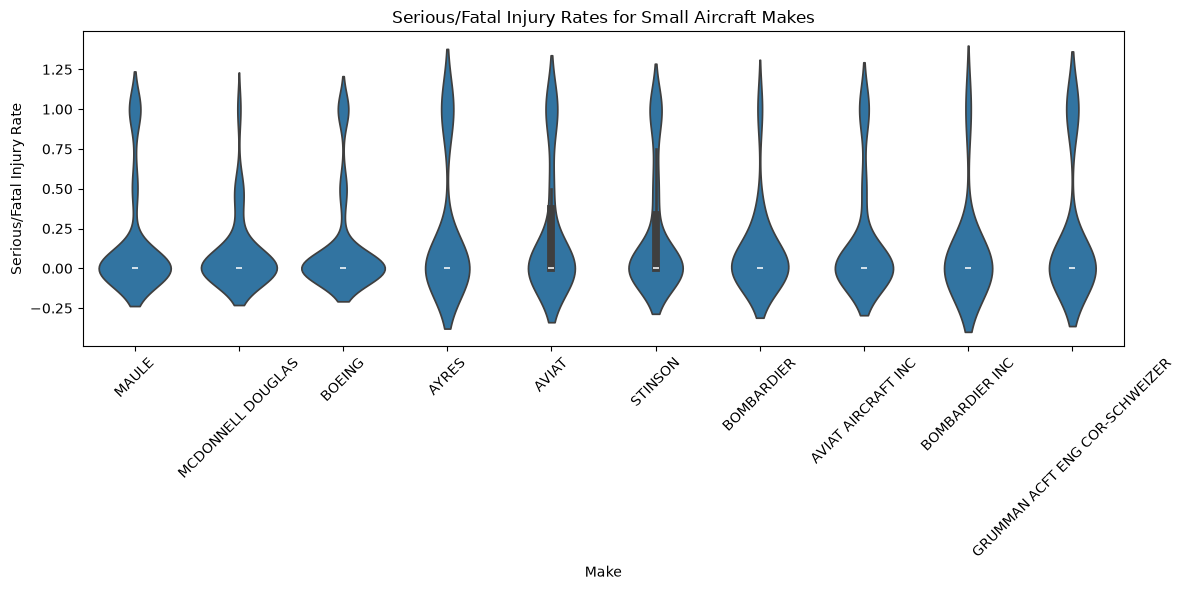

In [11]:
# Get the 10 small-aircraft makes with the lowest mean serious/fatal injury rates
small_top10_makes = small_make_rates.head(10).index

# Filter small aircraft to only those 10 makes
small_top10 = small_planes[
    small_planes["Make"].isin(small_top10_makes)
]

# Plot the distribution of serious/fatal injury rates
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=small_top10,
    x="Make",
    y="Serious.Fatal.Rate"
)

plt.title("Serious/Fatal Injury Rates for Small Aircraft Makes")
plt.xlabel("Make")
plt.ylabel("Serious/Fatal Injury Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

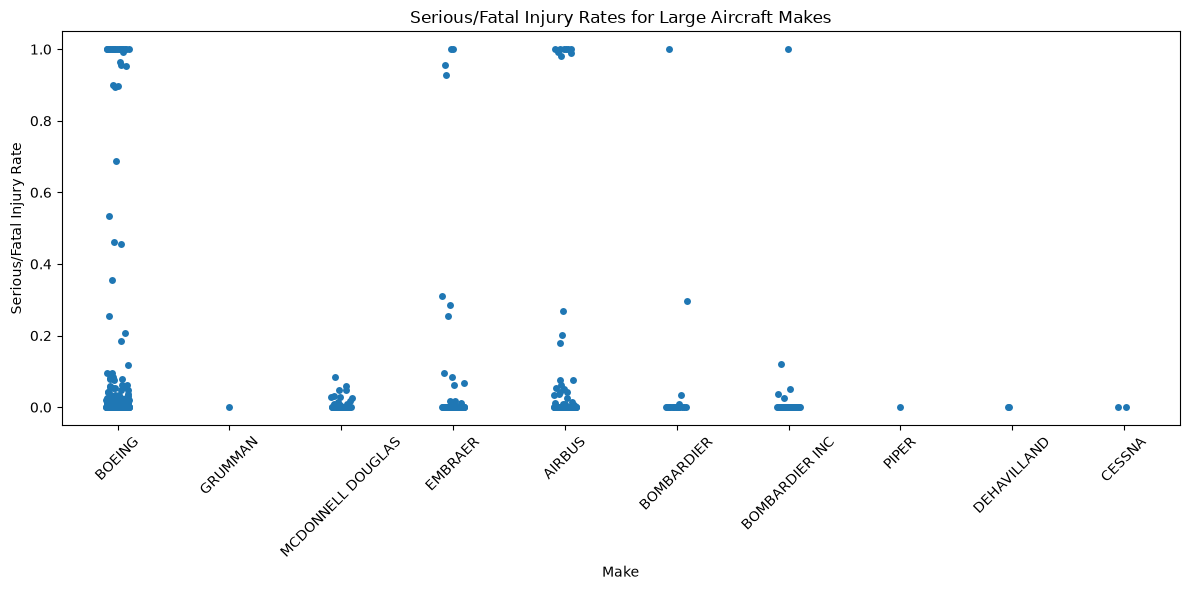

In [12]:
# Get the 10 large-aircraft makes with the lowest mean serious/fatal injury rates
large_top10_makes = large_make_rates.head(10).index

# Filter large aircraft to only those 10 makes
large_top10 = large_planes[
    large_planes["Make"].isin(large_top10_makes)
]

# Plot the distribution of serious/fatal injury rates
plt.figure(figsize=(12, 6))

sns.stripplot(
    data=large_top10,
    x="Make",
    y="Serious.Fatal.Rate"
)

plt.title("Serious/Fatal Injury Rates for Large Aircraft Makes")
plt.xlabel("Make")
plt.ylabel("Serious/Fatal Injury Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [13]:
# Calculate destruction rate by Make for small aircraft
small_destroyed_rates = (
    small_planes.groupby("Make")["Destroyed"]
    .mean()
    .sort_values()
    .head(15)
)

# Calculate destruction rate by Make for large aircraft
large_destroyed_rates = (
    large_planes.groupby("Make")["Destroyed"]
    .mean()
    .sort_values()
    .head(15)
)

display(small_destroyed_rates)
display(large_destroyed_rates)

Make
LUSCOMBE                          0.014493
GRUMMAN ACFT ENG COR-SCHWEIZER    0.017241
STINSON                           0.023256
TAYLORCRAFT                       0.032258
AERONCA                           0.035000
ERCOUPE                           0.038462
AMERICAN CHAMPION AIRCRAFT        0.039216
AVIAT AIRCRAFT INC                0.040000
MAULE                             0.041860
DEHAVILLAND                       0.044944
BELLANCA                          0.050459
DIAMOND AIRCRAFT IND INC          0.054054
BOMBARDIER                        0.055556
BOEING                            0.067183
CHAMPION                          0.076433
Name: Destroyed, dtype: float64

Make
DEHAVILLAND                  0.000000
RAYTHEON AIRCRAFT COMPANY    0.000000
BOMBARDIER INC               0.037037
BOMBARDIER                   0.055556
EMBRAER                      0.088889
BOEING                       0.096774
MCDONNELL DOUGLAS            0.111111
AIRBUS                       0.169811
DE HAVILLAND                 0.285714
BEECH                        1.000000
CESSNA                            NaN
GRUMMAN                           NaN
PIPER                             NaN
Name: Destroyed, dtype: float64

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

In [ ]:
### Discussion

For smaller aircraft, **Grumman Acft Eng Cor-Schweizer, Stinson, Aviat Aircraft Inc., Maule, and DeHavilland** performed relatively well when considering both serious/fatal injury rates and destruction rates. For larger aircraft, **McDonnell Douglas, Bombardier, Boeing, and Embraer** showed relatively low rates across both measures.

The violin and strip plots show that individual accident outcomes still vary even among makes with low averages. Some large-aircraft makes also had limited or missing destruction data, so those results should be interpreted cautiously. Overall, these recommendations reflect performance among recorded accidents, not overall accident probability.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

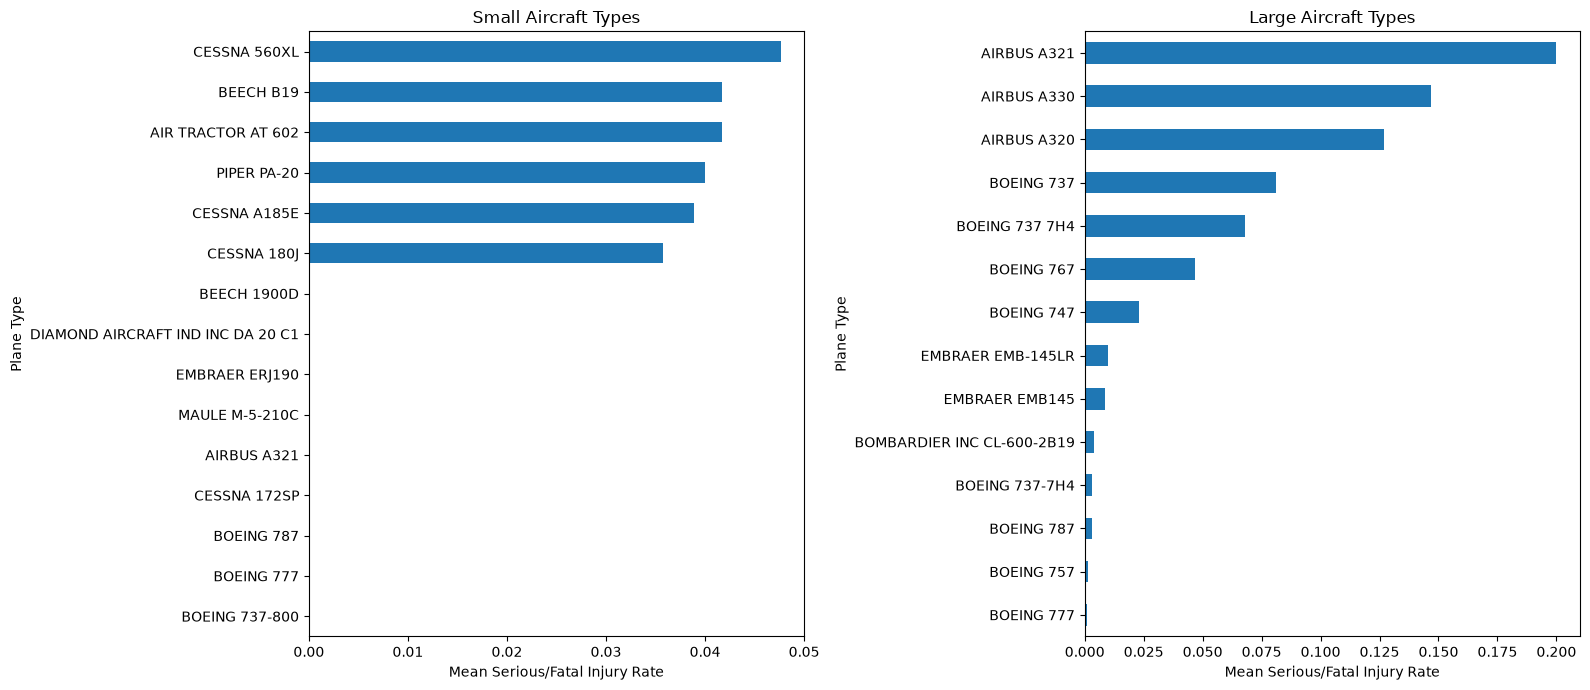

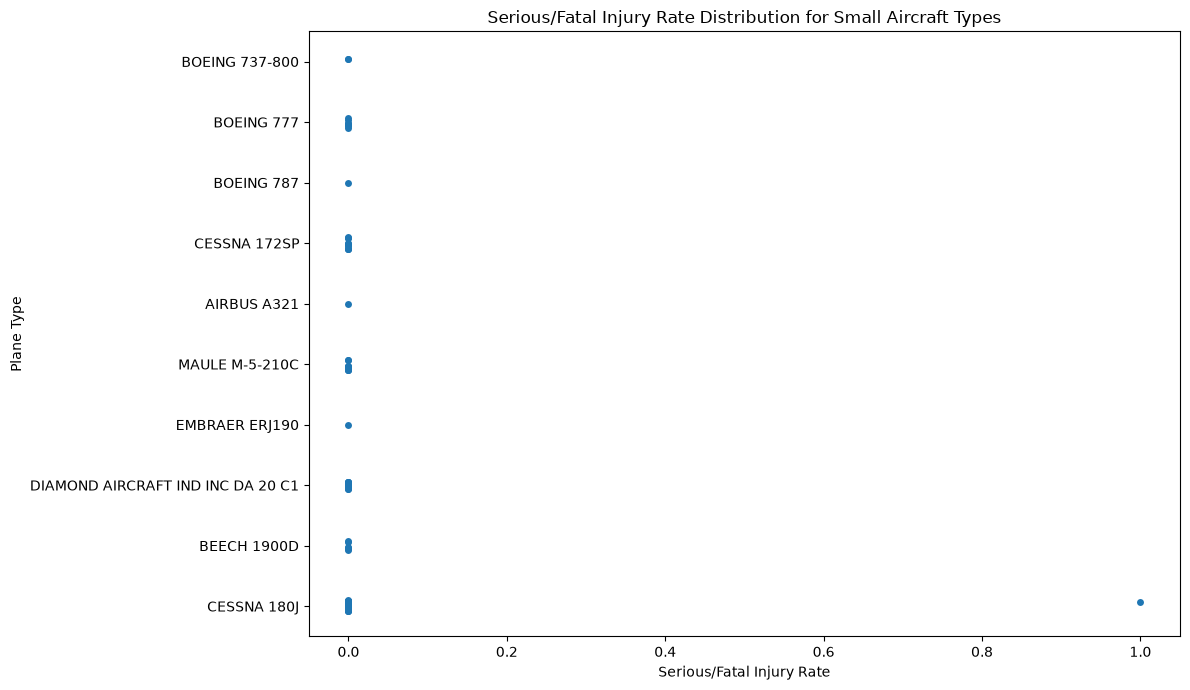

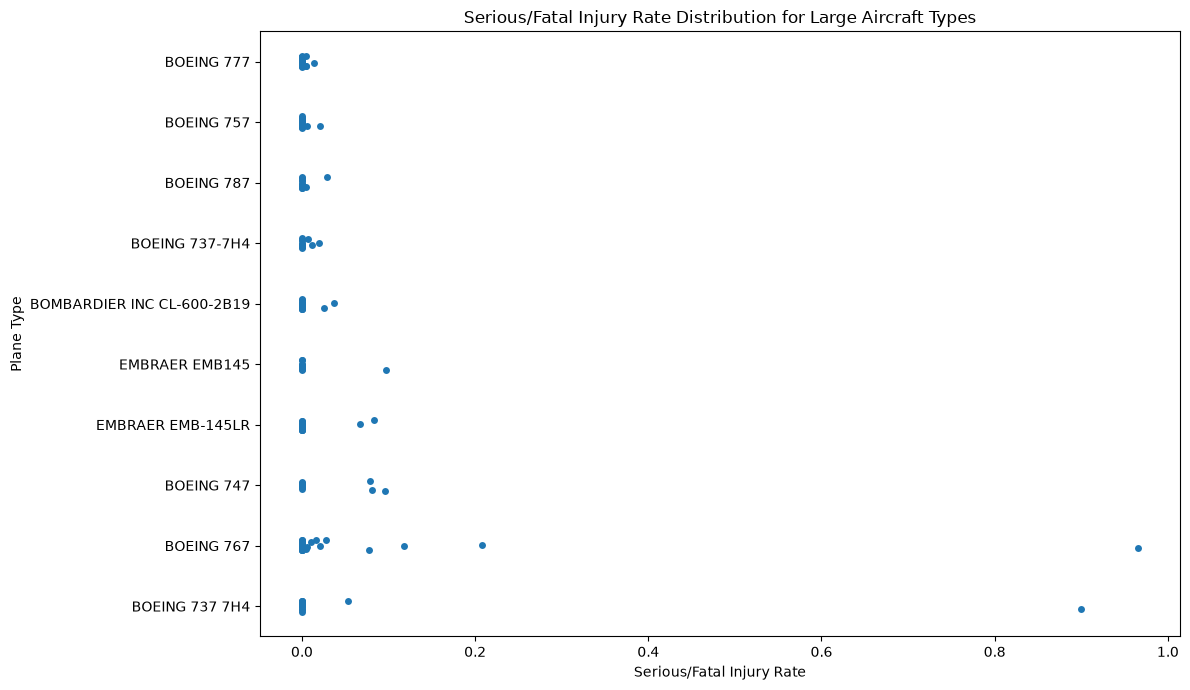

In [14]:
# Count the number of examples for each plane type
small_type_counts = small_planes["Plane.Type"].value_counts()
large_type_counts = large_planes["Plane.Type"].value_counts()

# Keep only plane types with at least 10 examples
valid_small_types = small_type_counts[small_type_counts >= 10].index
valid_large_types = large_type_counts[large_type_counts >= 10].index

small_types = small_planes[
    small_planes["Plane.Type"].isin(valid_small_types)
].copy()

large_types = large_planes[
    large_planes["Plane.Type"].isin(valid_large_types)
].copy()

# Calculate mean serious/fatal injury rate by plane type
small_type_rates = (
    small_types.groupby("Plane.Type")["Serious.Fatal.Rate"]
    .mean()
    .sort_values()
)

large_type_rates = (
    large_types.groupby("Plane.Type")["Serious.Fatal.Rate"]
    .mean()
    .sort_values()
)

# Plot mean injury rates
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

small_type_rates.head(15).plot(
    kind="barh",
    ax=axes[0]
)
axes[0].set_title("Small Aircraft Types")
axes[0].set_xlabel("Mean Serious/Fatal Injury Rate")
axes[0].set_ylabel("Plane Type")

large_type_rates.head(15).plot(
    kind="barh",
    ax=axes[1]
)
axes[1].set_title("Large Aircraft Types")
axes[1].set_xlabel("Mean Serious/Fatal Injury Rate")
axes[1].set_ylabel("Plane Type")

plt.tight_layout()
plt.show()

# Distribution plot for small aircraft types
small_plot_types = small_type_rates.head(10).index
small_type_plot_data = small_types[
    small_types["Plane.Type"].isin(small_plot_types)
]

plt.figure(figsize=(12, 7))
sns.stripplot(
    data=small_type_plot_data,
    x="Serious.Fatal.Rate",
    y="Plane.Type",
    order=small_plot_types
)

plt.title("Serious/Fatal Injury Rate Distribution for Small Aircraft Types")
plt.xlabel("Serious/Fatal Injury Rate")
plt.ylabel("Plane Type")
plt.tight_layout()
plt.show()

# Distribution plot for large aircraft types
large_plot_types = large_type_rates.head(10).index
large_type_plot_data = large_types[
    large_types["Plane.Type"].isin(large_plot_types)
]

plt.figure(figsize=(12, 7))
sns.stripplot(
    data=large_type_plot_data,
    x="Serious.Fatal.Rate",
    y="Plane.Type",
    order=large_plot_types
)

plt.title("Serious/Fatal Injury Rate Distribution for Large Aircraft Types")
plt.xlabel("Serious/Fatal Injury Rate")
plt.ylabel("Plane Type")
plt.tight_layout()
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

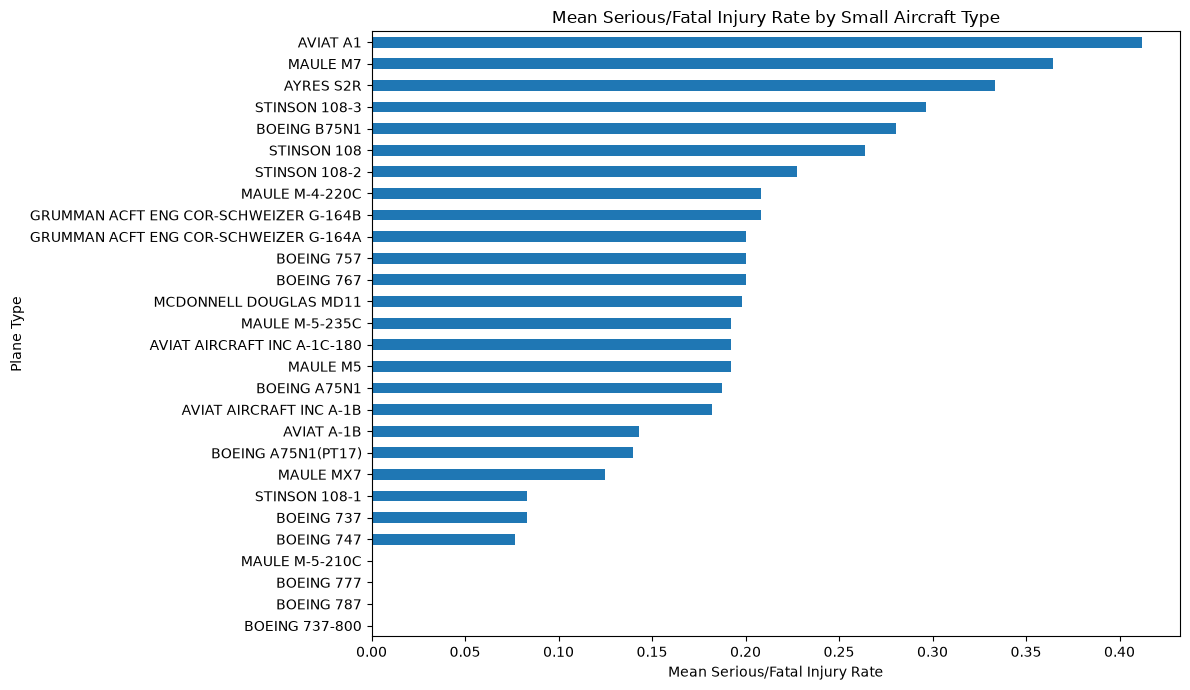

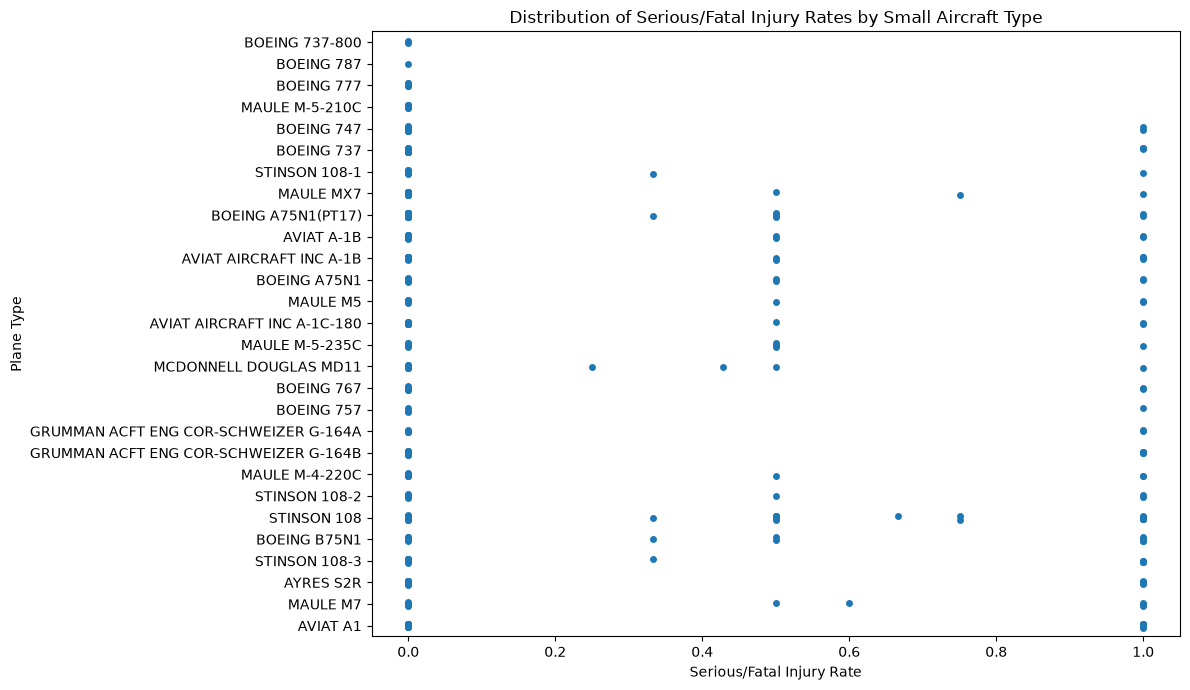

In [15]:
# Get the 10 small-aircraft makes with the lowest mean serious/fatal injury rates
small_top10_makes = (
    small_planes.groupby("Make")["Serious.Fatal.Rate"]
    .mean()
    .sort_values()
    .head(10)
    .index
)

# Limit small aircraft to those 10 makes
small_best_makes = small_planes[
    small_planes["Make"].isin(small_top10_makes)
].copy()

# Count examples of each plane type
small_type_counts = small_best_makes["Plane.Type"].value_counts()

# Keep only plane types with at least 10 examples
valid_small_types = small_type_counts[
    small_type_counts >= 10
].index

small_types = small_best_makes[
    small_best_makes["Plane.Type"].isin(valid_small_types)
].copy()

# Calculate mean serious/fatal injury rate for each plane type
small_type_rates = (
    small_types.groupby("Plane.Type")["Serious.Fatal.Rate"]
    .mean()
    .sort_values()
)

# Plot mean injury rates
plt.figure(figsize=(12, 7))

small_type_rates.plot(kind="barh")

plt.title("Mean Serious/Fatal Injury Rate by Small Aircraft Type")
plt.xlabel("Mean Serious/Fatal Injury Rate")
plt.ylabel("Plane Type")
plt.tight_layout()
plt.show()

# Plot distribution of injury rates
plt.figure(figsize=(12, 7))

sns.stripplot(
    data=small_types,
    x="Serious.Fatal.Rate",
    y="Plane.Type",
    order=small_type_rates.index
)

plt.title("Distribution of Serious/Fatal Injury Rates by Small Aircraft Type")
plt.xlabel("Serious/Fatal Injury Rate")
plt.ylabel("Plane Type")
plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

In [ ]:
### Discussion of Specific Airplane Types

For both small and large aircraft, serious/fatal injury rates varied between specific airplane models, even among models produced by manufacturers with relatively low overall injury rates. The distribution plots also show that individual accidents can have very different outcomes within the same airplane type.

By requiring at least 10 examples per airplane type, the model-level comparisons are less influenced by aircraft with only a few recorded accidents. Overall, the results suggest that both the manufacturer and the specific aircraft model should be considered when evaluating passenger injury risk.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

,Accident_Count,Mean_Serious_Fatal_Rate,Destroyed_Rate
Weather.Condition,,,
VMC,14295,0.233090,0.072424
IMC,905,0.628008,0.367561


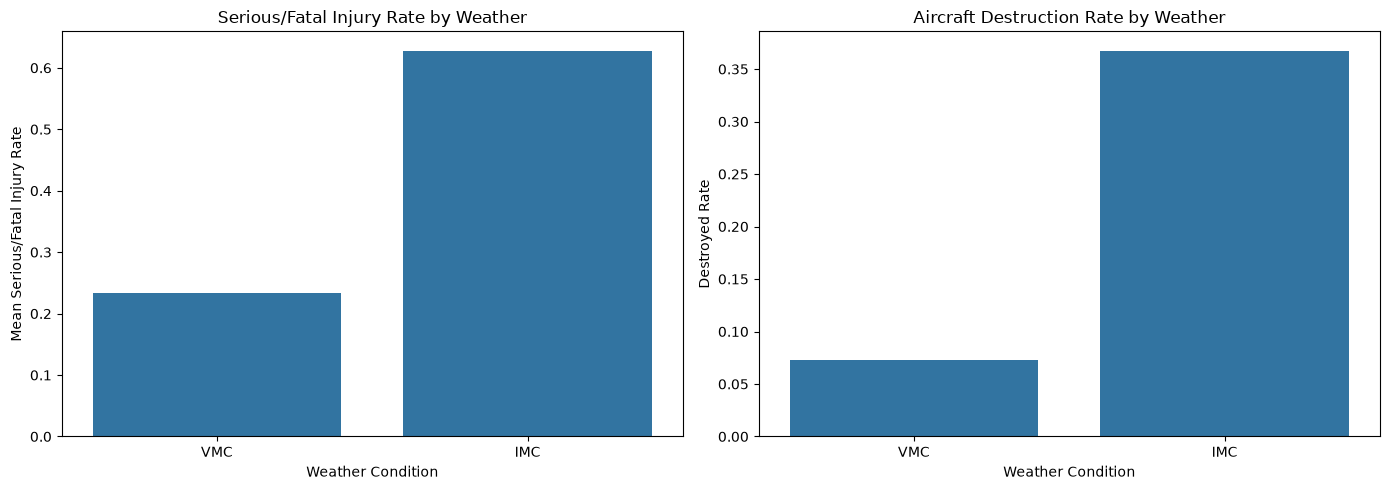

In [16]:
# Analyze injury and destruction rates by weather condition
weather_summary = (
    df.groupby("Weather.Condition")
    .agg(
        Accident_Count=("Event.Id", "count"),
        Mean_Serious_Fatal_Rate=("Serious.Fatal.Rate", "mean"),
        Destroyed_Rate=("Destroyed", "mean")
    )
    .sort_values("Mean_Serious_Fatal_Rate")
)

display(weather_summary)

# Visualize injury and destruction rates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=weather_summary.reset_index(),
    x="Weather.Condition",
    y="Mean_Serious_Fatal_Rate",
    ax=axes[0]
)
axes[0].set_title("Serious/Fatal Injury Rate by Weather")
axes[0].set_xlabel("Weather Condition")
axes[0].set_ylabel("Mean Serious/Fatal Injury Rate")

sns.barplot(
    data=weather_summary.reset_index(),
    x="Weather.Condition",
    y="Destroyed_Rate",
    ax=axes[1]
)
axes[1].set_title("Aircraft Destruction Rate by Weather")
axes[1].set_xlabel("Weather Condition")
axes[1].set_ylabel("Destroyed Rate")

plt.tight_layout()
plt.show()



In [ ]:
### Weather Condition

Weather condition showed a strong relationship with both injury severity and aircraft destruction. Accidents in IMC had a mean serious/fatal injury rate of about 0.63 compared with 0.23 in VMC. The destruction rate was also substantially higher in IMC (0.37) than VMC (0.07). This suggests that accidents occurring in instrument meteorological conditions tend to have more severe outcomes.

,Accident_Count,Mean_Serious_Fatal_Rate,Destroyed_Rate
Broad.phase.of.flight,,,
Landing,1110,0.008271,0.012613
Taxi,99,0.017338,0.010638
Go-around,81,0.086831,0.061728
Standing,35,0.093743,0.071429
Takeoff,425,0.108775,0.106132
Cruise,238,0.182796,0.137931
Approach,210,0.213239,0.110577
Descent,62,0.221954,0.175439
Climb,52,0.317611,0.300000


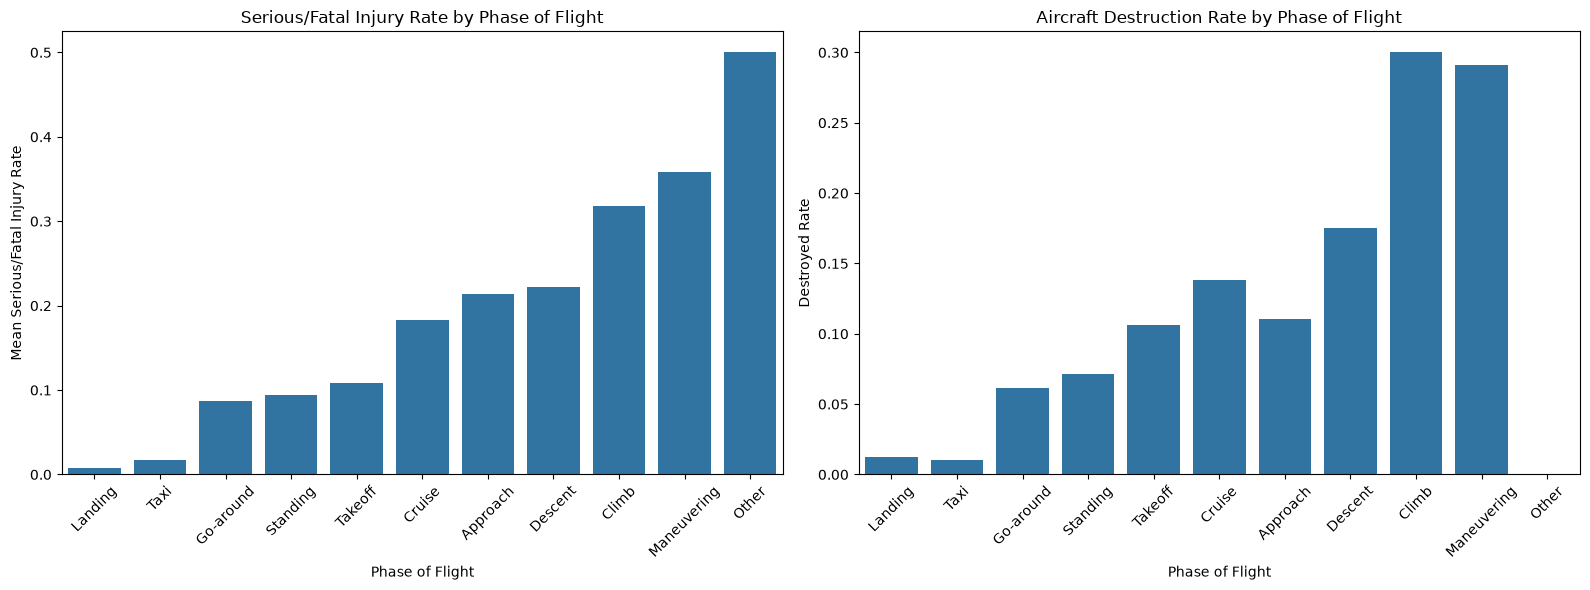

In [17]:
# Analyze injury and destruction rates by phase of flight
phase_summary = (
    df.groupby("Broad.phase.of.flight")
    .agg(
        Accident_Count=("Event.Id", "count"),
        Mean_Serious_Fatal_Rate=("Serious.Fatal.Rate", "mean"),
        Destroyed_Rate=("Destroyed", "mean")
    )
    .sort_values("Mean_Serious_Fatal_Rate")
)

display(phase_summary)

# Visualize injury and destruction rates
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=phase_summary.reset_index(),
    x="Broad.phase.of.flight",
    y="Mean_Serious_Fatal_Rate",
    ax=axes[0]
)
axes[0].set_title("Serious/Fatal Injury Rate by Phase of Flight")
axes[0].set_xlabel("Phase of Flight")
axes[0].set_ylabel("Mean Serious/Fatal Injury Rate")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    data=phase_summary.reset_index(),
    x="Broad.phase.of.flight",
    y="Destroyed_Rate",
    ax=axes[1]
)
axes[1].set_title("Aircraft Destruction Rate by Phase of Flight")
axes[1].set_xlabel("Phase of Flight")
axes[1].set_ylabel("Destroyed Rate")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
### Phase of Flight

Accident severity also varied by phase of flight. Landing had the lowest serious/fatal injury rate (0.008) and a low destruction rate (0.013), despite having the largest number of recorded accidents. In contrast, climbing and maneuvering had much higher injury and destruction rates. The "Other" category had only two observations, so its high injury rate is not reliable enough for comparison. Overall, the results suggest that the phase of flight is associated with the severity of an accident.